# Neural Style Transfer: Gender Vector Variations (Assignment)

Instructions:
- Load the pretrained generator from `generator_700.h5` in the project root.
- Load or define a gender vector.
- Generate 10 variations interpolating from male to female along the gender vector.
- Save generated images under `Assignments/outputs` and also display them inline.


In [1]:
import os
from pathlib import Path
import numpy as np
from PIL import Image

# Optional: silence TF logs before import
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

import tensorflow as tf
from tensorflow.keras.models import load_model

PROJECT_DIR = Path(r"D:/21days21aiprojects/L10_Creative_AI_Generating_Art _with_Neural_Style_Transfer")
ASSIGN_DIR = PROJECT_DIR / "Assignments"
OUTPUT_DIR = ASSIGN_DIR / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("TF version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


TF version: 2.19.0
GPU available: []


In [2]:
# Load pretrained generator
GENERATOR_PATH = PROJECT_DIR / "generator_700.h5"
assert GENERATOR_PATH.exists(), f"Generator not found at {GENERATOR_PATH}"

generator = load_model(GENERATOR_PATH, compile=False)
print("Loaded generator from:", GENERATOR_PATH)

# Try to infer latent size from the model input
if isinstance(generator.input_shape, list):
    latent_shape = generator.input_shape[0]
else:
    latent_shape = generator.input_shape

if isinstance(latent_shape, tuple):
    if len(latent_shape) == 2:
        latent_dim = latent_shape[1]
    else:
        latent_dim = int(np.prod(latent_shape[1:]))
else:
    latent_dim = int(latent_shape)

print("Inferred latent_dim:", latent_dim)


Loaded generator from: D:\21days21aiprojects\L10_Creative_AI_Generating_Art _with_Neural_Style_Transfer\generator_700.h5
Inferred latent_dim: 100


In [3]:
# Define or load gender direction vector in latent space
# If you have a precomputed gender vector file, you can load it here, e.g. np.load('gender_vector.npy')
# For this assignment, we'll create a random direction as a placeholder to demonstrate the pipeline.
# Replace this with the actual gender direction if available.

np.random.seed(42)
gender_direction = np.random.normal(size=(latent_dim,)).astype(np.float32)
# Normalize to unit length to control step sizes uniformly
gender_direction /= np.linalg.norm(gender_direction) + 1e-8

print("Gender direction vector ready. Norm:", np.linalg.norm(gender_direction))


Gender direction vector ready. Norm: 0.99999994


Prepared latent batch shape: (10, 100)
Generated output shape: (10, 128, 128, 3)


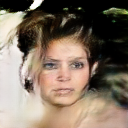

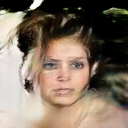

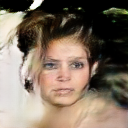

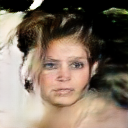

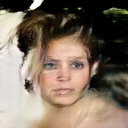

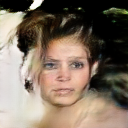

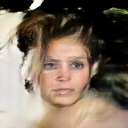

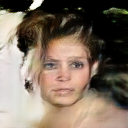

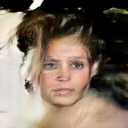

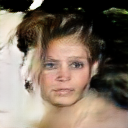

Saved:
- D:\21days21aiprojects\L10_Creative_AI_Generating_Art _with_Neural_Style_Transfer\Assignments\outputs\gender_variation_00_alpha_-1.00.png
- D:\21days21aiprojects\L10_Creative_AI_Generating_Art _with_Neural_Style_Transfer\Assignments\outputs\gender_variation_01_alpha_-0.78.png
- D:\21days21aiprojects\L10_Creative_AI_Generating_Art _with_Neural_Style_Transfer\Assignments\outputs\gender_variation_02_alpha_-0.56.png
- D:\21days21aiprojects\L10_Creative_AI_Generating_Art _with_Neural_Style_Transfer\Assignments\outputs\gender_variation_03_alpha_-0.33.png
- D:\21days21aiprojects\L10_Creative_AI_Generating_Art _with_Neural_Style_Transfer\Assignments\outputs\gender_variation_04_alpha_-0.11.png
- D:\21days21aiprojects\L10_Creative_AI_Generating_Art _with_Neural_Style_Transfer\Assignments\outputs\gender_variation_05_alpha_+0.11.png
- D:\21days21aiprojects\L10_Creative_AI_Generating_Art _with_Neural_Style_Transfer\Assignments\outputs\gender_variation_06_alpha_+0.33.png
- D:\21days21aiproje

In [4]:
# Generate 10 variations from male to female along the gender vector

# Base latent code (could be sampled or fixed). We use a fixed seed for reproducibility.
np.random.seed(123)
base_latent = np.random.normal(size=(latent_dim,)).astype(np.float32)

# Interpolation coefficients from -1.0 (male) to +1.0 (female)
num_variations = 10
alphas = np.linspace(-1.0, 1.0, num_variations).astype(np.float32)

latents = []
for a in alphas:
    latents.append(base_latent + a * gender_direction)

latents = np.stack(latents, axis=0)

# Some generators expect shape (batch, latent_dim); adjust if needed
# If model expects differently shaped input (e.g. (batch, 1, 1, latent_dim)), reshape accordingly
expected_rank = len(generator.input_shape)
if expected_rank == 2:
    model_input = latents
elif expected_rank == 4:
    # assume (batch, h, w, c) style latent (common in some DCGANs)
    h, w, c = generator.input_shape[1:]
    model_input = latents.reshape((num_variations, h, w, c))
else:
    model_input = latents

print("Prepared latent batch shape:", model_input.shape)

# Generate images
images = generator.predict(model_input, verbose=0)
print("Generated output shape:", images.shape)

# Post-process: scale to [0,255] uint8 assuming outputs in [-1,1] or [0,1]
img_min, img_max = images.min(), images.max()
# Heuristic normalization to 0..255
if img_min >= 0.0 and img_max <= 1.0:
    images_uint8 = (images * 255.0).clip(0, 255).astype(np.uint8)
elif img_min >= -1.0 and img_max <= 1.0:
    images_uint8 = (((images + 1.0) / 2.0) * 255.0).clip(0, 255).astype(np.uint8)
else:
    # fallback: min-max normalize per image
    imgs = []
    for i in range(images.shape[0]):
        im = images[i]
        im = (im - im.min()) / (im.max() - im.min() + 1e-8)
        imgs.append((im * 255.0).astype(np.uint8))
    images_uint8 = np.stack(imgs, axis=0)

# Ensure channel-last HWC order
if images_uint8.shape[-1] in (1, 3, 4):
    img_batch = images_uint8
else:
    # likely (N, C, H, W) -> (N, H, W, C)
    img_batch = np.transpose(images_uint8, (0, 2, 3, 1))

# Save images and display inline
from IPython.display import display

saved_paths = []
for idx, (a, img) in enumerate(zip(alphas, img_batch)):
    im = Image.fromarray(img)
    out_path = OUTPUT_DIR / f"gender_variation_{idx:02d}_alpha_{a:+.2f}.png"
    im.save(out_path)
    saved_paths.append(out_path)
    display(im)

print("Saved:")
for p in saved_paths:
    print("-", p)
